In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, pickle

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
import shap

In [29]:
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

with open('features.json') as f:
    FEATURES = json.load(f)

print(f'X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}   |  y_test  : {y_test.shape}')
print(f'\nFeatures ({len(FEATURES)}):', FEATURES)
print(f'\nAt-risk in test set: {y_test.sum()} / {len(y_test)} students')

X_train : (424, 21)  |  y_train : (424,)
X_test  : (79, 21)   |  y_test  : (79,)

Features (21): ['Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

At-risk in test set: 26 / 79 students


In [30]:
baseline_model = XGBClassifier(
    n_estimators     = 100,
    max_depth        = 4,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'logloss',
    random_state     = 42
)

baseline_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [31]:
def evaluate_model(model, X_test, y_test, label='Model', threshold=0.5):
    """Evaluate model at a given decision threshold."""
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred      = (y_pred_prob >= threshold).astype(int)  # FIX: use threshold

    metrics = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_test, y_pred_prob),
    }

    print(f'\n{"=" * 50}')
    print(f'  {label}  (threshold={threshold})')
    print(f'{"=" * 50}')
    for k, v in metrics.items():
        bar  = '█' * int(v * 20)
        flag = '  <-- KEY METRIC' if k == 'Recall' else ''
        print(f'  {k:12s}: {v:.4f}  {bar}{flag}')
    print(f'{"=" * 50}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Passing', 'At-Risk']))

    return metrics, y_pred, y_pred_prob


def plot_confusion_matrix(y_test, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Passing', 'At-Risk'],
                yticklabels=['Passing', 'At-Risk'],
                linewidths=1, linecolor='white')
    plt.title(title, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f'  True Positives  (caught at-risk)   : {tp}')
    print(f'  False Negatives (missed at-risk)   : {fn}  <-- minimize this')
    print(f'  False Positives (false alarms)     : {fp}')
    print(f'  True Negatives  (correctly passing): {tn}')

print('Helper functions defined.')

Helper functions defined.



  Baseline XGBoost  (threshold=0.5)
  Accuracy    : 0.9114  ██████████████████
  Precision   : 0.8800  █████████████████
  Recall      : 0.8462  ████████████████  <-- KEY METRIC
  F1-Score    : 0.8627  █████████████████
  ROC-AUC     : 0.9695  ███████████████████

Classification Report:
              precision    recall  f1-score   support

     Passing       0.93      0.94      0.93        53
     At-Risk       0.88      0.85      0.86        26

    accuracy                           0.91        79
   macro avg       0.90      0.89      0.90        79
weighted avg       0.91      0.91      0.91        79



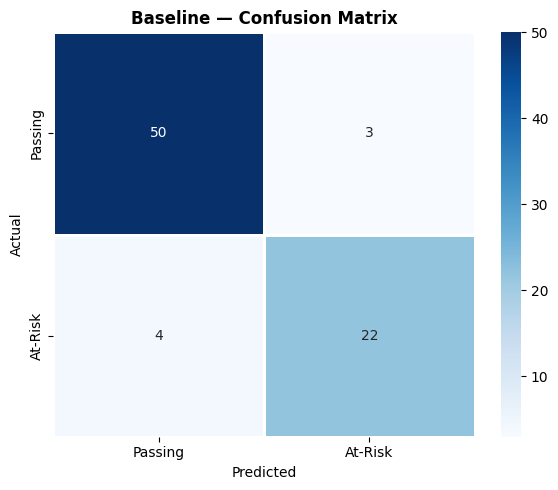

  True Positives  (caught at-risk)   : 22
  False Negatives (missed at-risk)   : 4  <-- minimize this
  False Positives (false alarms)     : 3
  True Negatives  (correctly passing): 50


In [32]:
baseline_metrics, y_pred_base, y_prob_base = evaluate_model(
    baseline_model, X_test, y_test, label='Baseline XGBoost'
)
plot_confusion_matrix(y_test, y_pred_base, 'Baseline — Confusion Matrix')

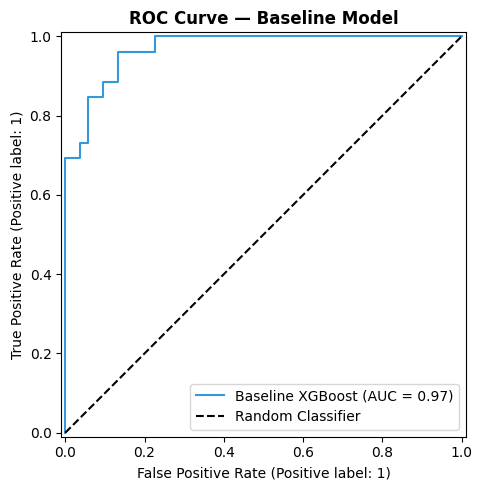

In [33]:
# ROC Curve — Baseline
fig, ax = plt.subplots(figsize=(7, 5))  # FIX: create axes first, avoids blank figure issue
RocCurveDisplay.from_predictions(y_test, y_prob_base,
                                  name='Baseline XGBoost',
                                  color='#3498db', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('ROC Curve — Baseline Model', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

xgb_base = XGBClassifier(eval_metric='logloss', random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid,
    scoring    = 'recall',
    cv         = cv,
    n_jobs     = -1,
    verbose    = 1
)

print('Running GridSearchCV... (this may take a few minutes)')
grid_search.fit(X_train, y_train)

print(f'\nBest CV Recall   : {grid_search.best_score_:.4f}')
print(f'Best Parameters  :')
for k, v in grid_search.best_params_.items():
    print(f'  {k:20s}: {v}')

Running GridSearchCV... (this may take a few minutes)
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Best CV Recall   : 0.9579
Best Parameters  :
  colsample_bytree    : 1.0
  learning_rate       : 0.05
  max_depth           : 3
  n_estimators        : 100
  subsample           : 0.8


In [35]:
best_params = grid_search.best_params_

tuned_model = XGBClassifier(
    **best_params,
    eval_metric='logloss',
    random_state=42
)

tuned_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


  Tuned XGBoost  (threshold=0.5)
  Accuracy    : 0.9114  ██████████████████
  Precision   : 0.8800  █████████████████
  Recall      : 0.8462  ████████████████  <-- KEY METRIC
  F1-Score    : 0.8627  █████████████████
  ROC-AUC     : 0.9724  ███████████████████

Classification Report:
              precision    recall  f1-score   support

     Passing       0.93      0.94      0.93        53
     At-Risk       0.88      0.85      0.86        26

    accuracy                           0.91        79
   macro avg       0.90      0.89      0.90        79
weighted avg       0.91      0.91      0.91        79



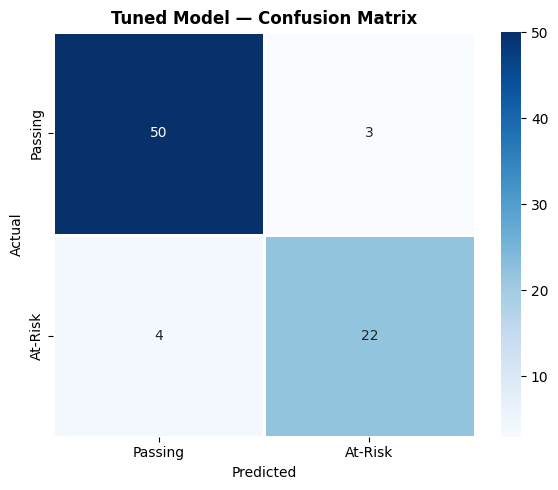

  True Positives  (caught at-risk)   : 22
  False Negatives (missed at-risk)   : 4  <-- minimize this
  False Positives (false alarms)     : 3
  True Negatives  (correctly passing): 50


In [36]:
tuned_metrics, y_pred_tuned, y_prob_tuned = evaluate_model(
    tuned_model, X_test, y_test, label='Tuned XGBoost'
)
plot_confusion_matrix(y_test, y_pred_tuned, 'Tuned Model — Confusion Matrix')

Metric Comparison:
           Baseline   Tuned
Accuracy     0.9114  0.9114
Precision    0.8800  0.8800
Recall       0.8462  0.8462
F1-Score     0.8627  0.8627
ROC-AUC      0.9695  0.9724


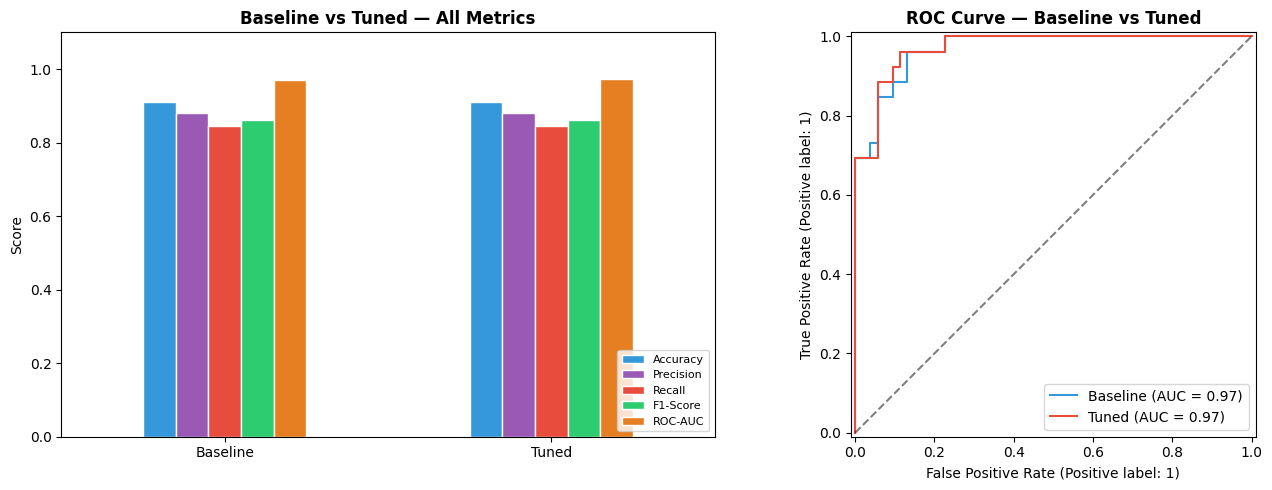

In [37]:
comparison_df = pd.DataFrame({
    'Baseline': baseline_metrics,
    'Tuned'   : tuned_metrics
})

print('Metric Comparison:')
print(comparison_df.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar comparison
comparison_df.T.plot(kind='bar', ax=axes[0],
                     color=['#3498db','#9b59b6','#e74c3c','#2ecc71','#e67e22'],
                     edgecolor='white', rot=0)
axes[0].set_title('Baseline vs Tuned — All Metrics', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend(loc='lower right', fontsize=8)

# ROC overlay
RocCurveDisplay.from_predictions(y_test, y_prob_base,  name='Baseline', color='#3498db', ax=axes[1])
RocCurveDisplay.from_predictions(y_test, y_prob_tuned, name='Tuned',    color='#e74c3c', ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('ROC Curve — Baseline vs Tuned', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [38]:
# Sweep thresholds from 0.5 down to 0.2 and track metrics
thresholds = np.arange(0.50, 0.19, -0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob_tuned >= t).astype(int)
    threshold_results.append({
        'threshold': round(t, 2),
        'Recall'   : recall_score(y_test, y_pred_t, zero_division=0),
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred_t, zero_division=0),
        'Accuracy' : accuracy_score(y_test, y_pred_t),
        'FN'       : confusion_matrix(y_test, y_pred_t).ravel()[2],  # false negatives
        'FP'       : confusion_matrix(y_test, y_pred_t).ravel()[1],  # false positives
    })

thresh_df = pd.DataFrame(threshold_results)
print('Threshold Analysis:')
print(thresh_df.to_string(index=False))

Threshold Analysis:
 threshold   Recall  Precision  F1-Score  Accuracy  FN  FP
      0.50 0.846154   0.880000  0.862745  0.911392   4   3
      0.45 0.846154   0.880000  0.862745  0.911392   4   3
      0.40 0.884615   0.821429  0.851852  0.898734   3   5
      0.35 0.884615   0.821429  0.851852  0.898734   3   5
      0.30 0.884615   0.821429  0.851852  0.898734   3   5
      0.25 0.884615   0.821429  0.851852  0.898734   3   5
      0.20 0.961538   0.781250  0.862069  0.898734   1   7


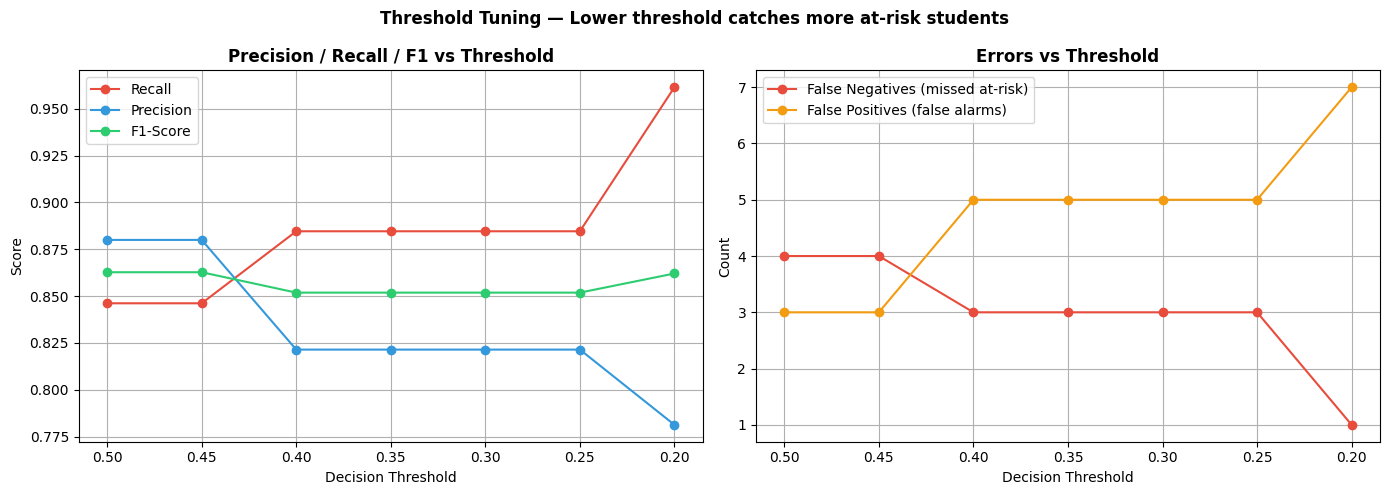

In [39]:
# Plot Precision-Recall tradeoff across thresholds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresh_df['threshold'], thresh_df['Recall'],    'o-', color='#e74c3c', label='Recall')
axes[0].plot(thresh_df['threshold'], thresh_df['Precision'], 'o-', color='#3498db', label='Precision')
axes[0].plot(thresh_df['threshold'], thresh_df['F1-Score'],  'o-', color='#2ecc71', label='F1-Score')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
axes[0].legend()
axes[0].invert_xaxis()
axes[0].grid(True)

axes[1].plot(thresh_df['threshold'], thresh_df['FN'], 'o-', color='#e74c3c', label='False Negatives (missed at-risk)')
axes[1].plot(thresh_df['threshold'], thresh_df['FP'], 'o-', color='#f39c12', label='False Positives (false alarms)')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Count')
axes[1].set_title('Errors vs Threshold', fontweight='bold')
axes[1].legend()
axes[1].invert_xaxis()
axes[1].grid(True)

plt.suptitle('Threshold Tuning — Lower threshold catches more at-risk students', fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
# Pick the best threshold: maximize Recall while keeping F1 above 0.80
valid = thresh_df[thresh_df['F1-Score'] >= 0.80]
best_thresh_row = valid.loc[valid['Recall'].idxmax()]
BEST_THRESHOLD  = best_thresh_row['threshold']

print(f'Selected threshold : {BEST_THRESHOLD}')
print(f'  Recall           : {best_thresh_row["Recall"]:.4f}')
print(f'  Precision        : {best_thresh_row["Precision"]:.4f}')
print(f'  F1-Score         : {best_thresh_row["F1-Score"]:.4f}')
print(f'  False Negatives  : {int(best_thresh_row["FN"])}  (missed at-risk students)')
print(f'  False Positives  : {int(best_thresh_row["FP"])}  (false alarms)')

Selected threshold : 0.2
  Recall           : 0.9615
  Precision        : 0.7812
  F1-Score         : 0.8621
  False Negatives  : 1  (missed at-risk students)
  False Positives  : 7  (false alarms)



  Tuned XGBoost (best threshold)  (threshold=0.2)
  Accuracy    : 0.8987  █████████████████
  Precision   : 0.7812  ███████████████
  Recall      : 0.9615  ███████████████████  <-- KEY METRIC
  F1-Score    : 0.8621  █████████████████
  ROC-AUC     : 0.9724  ███████████████████

Classification Report:
              precision    recall  f1-score   support

     Passing       0.98      0.87      0.92        53
     At-Risk       0.78      0.96      0.86        26

    accuracy                           0.90        79
   macro avg       0.88      0.91      0.89        79
weighted avg       0.91      0.90      0.90        79



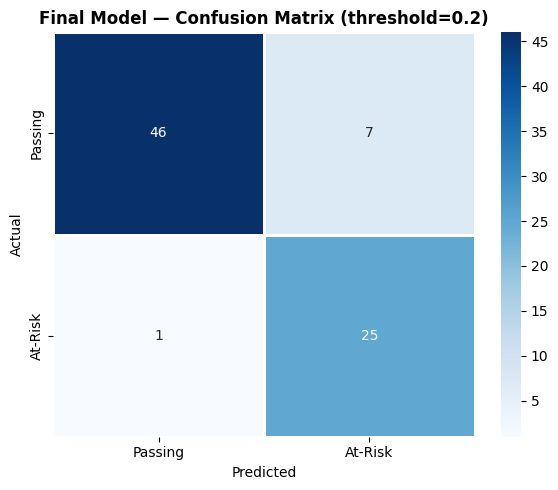

  True Positives  (caught at-risk)   : 25
  False Negatives (missed at-risk)   : 1  <-- minimize this
  False Positives (false alarms)     : 7
  True Negatives  (correctly passing): 46


In [41]:
final_metrics, y_pred_final, _ = evaluate_model(
    tuned_model, X_test, y_test,
    label='Tuned XGBoost (best threshold)',
    threshold=BEST_THRESHOLD
)
plot_confusion_matrix(y_test, y_pred_final,
                      f'Final Model — Confusion Matrix (threshold={BEST_THRESHOLD})')

In [42]:
final_model = tuned_model  # tuned model + BEST_THRESHOLD applied at predict time

print('Final model: Tuned XGBoost')
print(f'Decision threshold: {BEST_THRESHOLD}')
print(f'\nFinal Metrics:')
for k, v in final_metrics.items():
    print(f'  {k:12s}: {v:.4f}')

Final model: Tuned XGBoost
Decision threshold: 0.2

Final Metrics:
  Accuracy    : 0.8987
  Precision   : 0.7812
  Recall      : 0.9615
  F1-Score    : 0.8621
  ROC-AUC     : 0.9724


In [43]:
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

print(f'SHAP values computed for {X_test.shape[0]} test samples')
print(f'SHAP values shape: {np.array(shap_values).shape}')

SHAP values computed for 79 test samples
SHAP values shape: (79, 21)


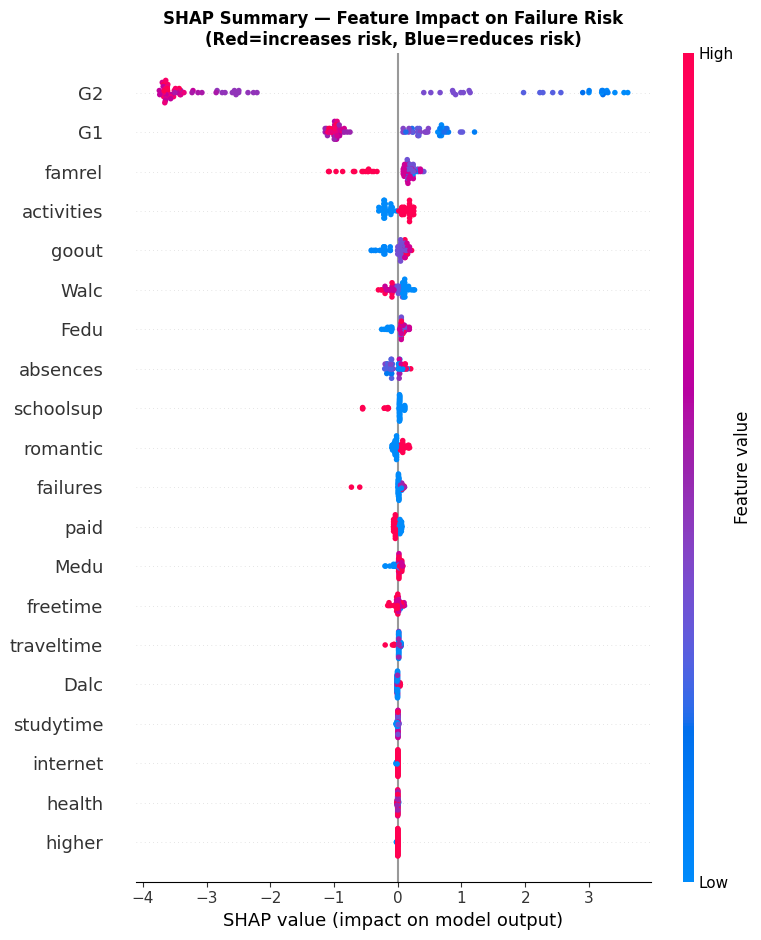

In [44]:
# SHAP Summary Plot — feature impact with direction (dot = one student)
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP Summary — Feature Impact on Failure Risk\n(Red=increases risk, Blue=reduces risk)',
          fontweight='bold')
plt.tight_layout()
plt.show()

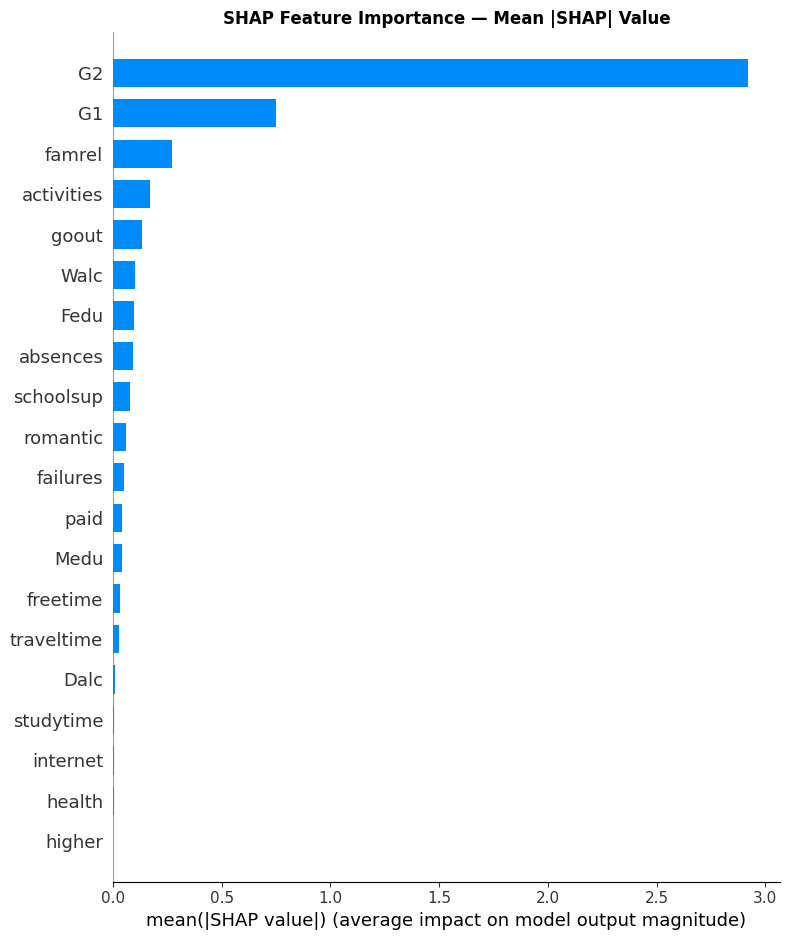

In [45]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=FEATURES,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Mean |SHAP| Value', fontweight='bold')
plt.tight_layout()
plt.show()

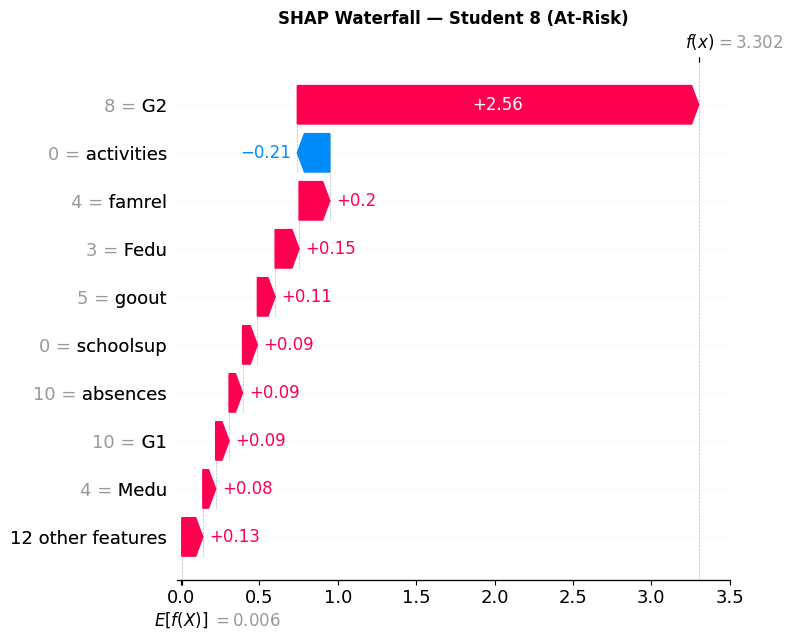

Student 8 data:
Medu           4
Fedu           3
traveltime     2
studytime      2
failures       0
schoolsup      0
famsup         1
paid           1
activities     0
higher         1
internet       1
romantic       1
famrel         4
freetime       4
goout          5
Dalc           1
Walc           2
health         2
absences      10
G1            10
G2             8


In [46]:
# SHAP Waterfall — explain one at-risk student
at_risk_idx = y_test[y_test == 1].index[3]
sample_pos  = X_test.index.get_loc(at_risk_idx)

shap_explanation = shap.Explanation(
    values        = shap_values[sample_pos],
    base_values   = explainer.expected_value,
    data          = X_test.iloc[sample_pos].values,
    feature_names = FEATURES
)

plt.figure()
shap.waterfall_plot(shap_explanation, show=False)
plt.title(f'SHAP Waterfall — Student {at_risk_idx} (At-Risk)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Student {at_risk_idx} data:')
print(X_test.loc[at_risk_idx].to_string())

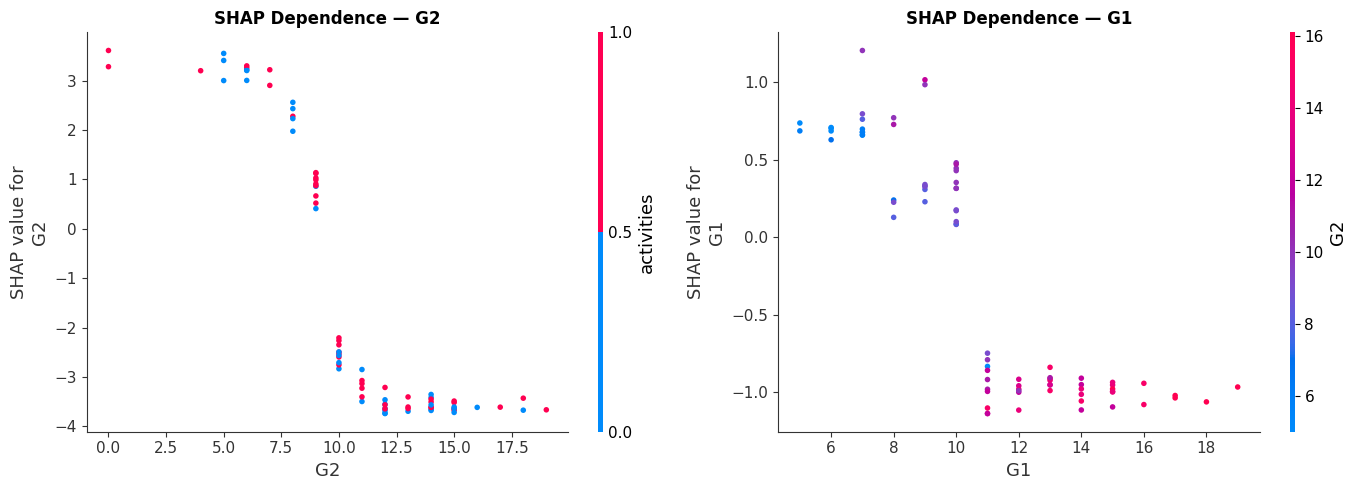

In [47]:
# SHAP Dependence plots — top 2 most important features
# Get top 2 features by mean absolute SHAP value
mean_shap   = np.abs(shap_values).mean(axis=0)
top2_idx    = np.argsort(mean_shap)[::-1][:2]
top2_feats  = [FEATURES[i] for i in top2_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, feat in enumerate(top2_feats):
    shap.dependence_plot(feat, shap_values, X_test,
                         feature_names=FEATURES, ax=axes[i], show=False)
    axes[i].set_title(f'SHAP Dependence — {feat}', fontweight='bold')

plt.tight_layout()
plt.show()

Risk Band Distribution:
risk_band
LOW       51
HIGH      24
MEDIUM     4
Name: count, dtype: int64


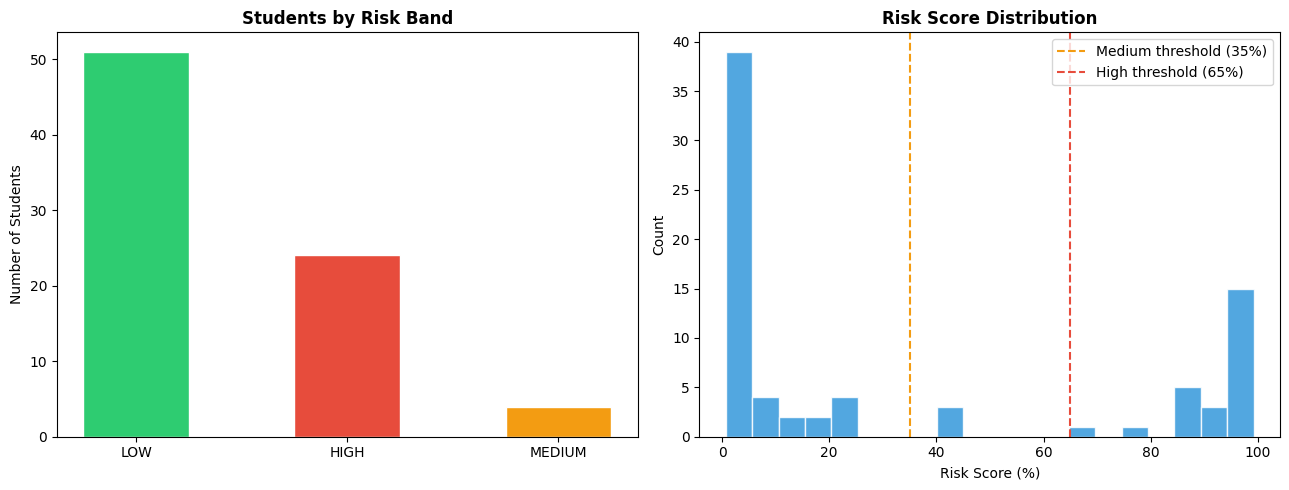


Top 10 Highest Risk Students:
    risk_score risk_band  actual  prediction
67        99.2      HIGH       1           1
45        99.0      HIGH       1           1
72        99.0      HIGH       1           1
54        98.9      HIGH       1           1
78        98.7      HIGH       1           1
0         98.4      HIGH       1           1
20        98.2      HIGH       1           1
13        97.8      HIGH       1           1
34        97.8      HIGH       1           1
33        97.4      HIGH       1           1


In [48]:
# FIX: Adjusted band thresholds — 0.40/0.70 left MEDIUM almost empty (only 4 students)
# New thresholds: LOW < 35%, MEDIUM 35-65%, HIGH >= 65%
RISK_LOW_THRESHOLD    = 0.35
RISK_HIGH_THRESHOLD   = 0.65

def get_risk_band(prob):
    if prob >= RISK_HIGH_THRESHOLD:
        return 'HIGH'
    elif prob >= RISK_LOW_THRESHOLD:
        return 'MEDIUM'
    else:
        return 'LOW'

risk_df = X_test.copy()
risk_df['actual']     = y_test.values
risk_df['risk_score'] = [round(float(p) * 100, 1) for p in y_prob_tuned]  # FIX: float formatting
risk_df['risk_band']  = [get_risk_band(p) for p in y_prob_tuned]
risk_df['prediction'] = (y_prob_tuned >= BEST_THRESHOLD).astype(int)

print('Risk Band Distribution:')
print(risk_df['risk_band'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_map  = {'LOW': '#2ecc71', 'MEDIUM': '#f39c12', 'HIGH': '#e74c3c'}
band_counts = risk_df['risk_band'].value_counts()
axes[0].bar(band_counts.index,
            band_counts.values,
            color=[colors_map[b] for b in band_counts.index],
            edgecolor='white', width=0.5)
axes[0].set_title('Students by Risk Band', fontweight='bold')
axes[0].set_ylabel('Number of Students')

axes[1].hist(risk_df['risk_score'], bins=20,
             color='#3498db', edgecolor='white', alpha=0.85)
axes[1].axvline(x=RISK_LOW_THRESHOLD*100,  color='#f39c12', linestyle='--',
                label=f'Medium threshold ({int(RISK_LOW_THRESHOLD*100)}%)')
axes[1].axvline(x=RISK_HIGH_THRESHOLD*100, color='#e74c3c', linestyle='--',
                label=f'High threshold ({int(RISK_HIGH_THRESHOLD*100)}%)')
axes[1].set_title('Risk Score Distribution', fontweight='bold')
axes[1].set_xlabel('Risk Score (%)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nTop 10 Highest Risk Students:')
print(risk_df[['risk_score', 'risk_band', 'actual', 'prediction']]
      .sort_values('risk_score', ascending=False)
      .head(10)
      .to_string())

In [49]:
# Global direction map: what does a HIGH value of each feature generally mean for risk?
# Used to show faculty the feature's typical meaning, separate from the local SHAP sign
FEATURE_CONTEXT = {
    'G1'        : {'high': 'good (reduces risk)',   'low': 'bad (increases risk)'},
    'G2'        : {'high': 'good (reduces risk)',   'low': 'bad (increases risk)'},
    'failures'  : {'high': 'bad (increases risk)',  'low': 'good (reduces risk)'},
    'absences'  : {'high': 'bad (increases risk)',  'low': 'good (reduces risk)'},
    'studytime' : {'high': 'good (reduces risk)',   'low': 'bad (increases risk)'},
    'Dalc'      : {'high': 'bad (increases risk)',  'low': 'good (reduces risk)'},
    'Walc'      : {'high': 'bad (increases risk)',  'low': 'good (reduces risk)'},
    'goout'     : {'high': 'risky (distraction)',   'low': 'neutral'},
    'higher'    : {'high': 'good (motivated)',      'low': 'bad (unmotivated)'},
    'internet'  : {'high': 'good (access)',         'low': 'bad (no resources)'},
    'Medu'      : {'high': 'good (support)',        'low': 'bad (low support)'},
    'Fedu'      : {'high': 'good (support)',        'low': 'bad (low support)'},
    'famrel'    : {'high': 'good (stable home)',    'low': 'bad (unstable home)'},
    'health'    : {'high': 'good',                  'low': 'bad (affects attendance)'},
    'schoolsup' : {'high': 'already flagged',       'low': 'no support yet'},
    'famsup'    : {'high': 'has family support',    'low': 'no family support'},
    'romantic'  : {'high': 'possible distraction',  'low': 'neutral'},
    'traveltime': {'high': 'long commute',          'low': 'short commute'},
    'freetime'  : {'high': 'lots of free time',     'low': 'little free time'},
    'paid'      : {'high': 'extra tutoring',        'low': 'no extra tutoring'},
    'activities': {'high': 'extracurricular',       'low': 'no extracurriculars'},
}

def predict_student(student_data: dict, model, explainer, features,
                    threshold=0.5):
    """
    Predict failure risk for one student.
    Shows feature values + global meaning + local SHAP contribution.
    """
    df_input   = pd.DataFrame([student_data])[features]
    prob       = float(model.predict_proba(df_input)[0][1])
    risk_score = round(prob * 100, 1)          # FIX: clean float formatting
    risk_band  = get_risk_band(prob)
    prediction = 'AT-RISK' if prob >= threshold else 'PASSING'

    sv         = explainer.shap_values(df_input)[0]
    shap_dict  = dict(zip(features, sv))
    top_factors = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:5]

    return {
        'risk_score' : risk_score,
        'risk_band'  : risk_band,
        'prediction' : prediction,
        'top_factors': top_factors,
        'all_shap'   : shap_dict,
        'input_data' : student_data,
    }


def display_prediction(result, features_context=FEATURE_CONTEXT):
    """Display prediction in faculty-friendly format with correct context."""
    print('=' * 60)
    print('  FAILSAFE — Student Risk Assessment')
    print('=' * 60)
    print(f'  Risk Score  : {result["risk_score"]}%')
    print(f'  Risk Band   : {result["risk_band"]}')
    print(f'  Prediction  : {result["prediction"]}')
    print()
    print('  Top 5 Contributing Factors:')
    print(f'  {"Feature":15s}  {"Value":>6}  {"SHAP":>8}  {"Meaning"}')
    print(f'  {"-"*15}  {"-"*6}  {"-"*8}  {"-"*25}')

    for feat, shap_val in result['top_factors']:
        val = result['input_data'].get(feat, 'N/A')
        # FIX: show the global meaning of the feature value, not just SHAP sign
        ctx = features_context.get(feat, {})
        # Determine if value is high or low (midpoint of typical range)
        # For binary: 1=high, 0=low. For scales: use 3 as midpoint
        if isinstance(val, (int, float)):
            meaning = ctx.get('high') if val >= 1 else ctx.get('low', '')
        else:
            meaning = ''
        shap_dir = '+' if shap_val > 0 else '-'
        print(f'  {feat:15s}  {str(val):>6}  {shap_dir}{abs(shap_val):>7.4f}  {meaning}')

    print('=' * 60)
    print('  Note: SHAP +/- shows this feature\'s push on this student.')
    print('  Meaning column shows what that feature value generally implies.')
    print('=' * 60)


print('Prediction functions defined.')

Prediction functions defined.


In [50]:
# Test with a high-risk student profile
sample_student = {
    'traveltime': 2, 'studytime': 1, 'failures': 2,
    'schoolsup' : 0, 'famsup': 0,   'paid': 0,
    'activities': 0, 'higher': 0,   'internet': 0,
    'romantic'  : 1, 'famrel': 2,   'freetime': 4,
    'goout'     : 5, 'Dalc': 4,     'Walc': 5,
    'health'    : 2, 'absences': 18, 'G1': 6,
    'G2'        : 5, 'Medu': 1,     'Fedu': 1
}

result = predict_student(sample_student, final_model, explainer,
                         FEATURES, threshold=BEST_THRESHOLD)
display_prediction(result)

  FAILSAFE — Student Risk Assessment
  Risk Score  : 98.3%
  Risk Band   : HIGH
  Prediction  : AT-RISK

  Top 5 Contributing Factors:
  Feature           Value      SHAP  Meaning
  ---------------  ------  --------  -------------------------
  G2                    5  + 3.2771  good (reduces risk)
  G1                    6  + 0.7164  good (reduces risk)
  Walc                  5  - 0.1614  bad (increases risk)
  Fedu                  1  - 0.1515  good (support)
  famrel                2  + 0.1485  good (stable home)
  Note: SHAP +/- shows this feature's push on this student.
  Meaning column shows what that feature value generally implies.


In [51]:
# Test with a low-risk student profile for contrast
safe_student = {
    'traveltime': 1, 'studytime': 3, 'failures': 0,
    'schoolsup' : 0, 'famsup': 1,   'paid': 1,
    'activities': 1, 'higher': 1,   'internet': 1,
    'romantic'  : 0, 'famrel': 5,   'freetime': 2,
    'goout'     : 2, 'Dalc': 1,     'Walc': 1,
    'health'    : 5, 'absences': 2,  'G1': 15,
    'G2'        : 16,'Medu': 4,     'Fedu': 3
}

result_safe = predict_student(safe_student, final_model, explainer,
                              FEATURES, threshold=BEST_THRESHOLD)
display_prediction(result_safe)

  FAILSAFE — Student Risk Assessment
  Risk Score  : 0.8%
  Risk Band   : LOW
  Prediction  : PASSING

  Top 5 Contributing Factors:
  Feature           Value      SHAP  Meaning
  ---------------  ------  --------  -------------------------
  G2                   16  - 3.4591  good (reduces risk)
  G1                   15  - 0.8694  good (reduces risk)
  famrel                5  - 0.4757  good (stable home)
  goout                 2  - 0.1727  risky (distraction)
  absences              2  - 0.1115  bad (increases risk)
  Note: SHAP +/- shows this feature's push on this student.
  Meaning column shows what that feature value generally implies.


In [52]:
os.makedirs('models', exist_ok=True)

# Save trained model
with open('models/failsafe_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# Save SHAP explainer
with open('models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

# Save best params
with open('models/best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

# Save final metrics
with open('models/metrics.json', 'w') as f:
    json.dump({k: round(v, 4) for k, v in final_metrics.items()}, f, indent=2)

# Save threshold config — FastAPI needs this at predict time
thresh_config = {
    'decision_threshold'  : float(BEST_THRESHOLD),
    'risk_low_threshold'  : RISK_LOW_THRESHOLD,
    'risk_high_threshold' : RISK_HIGH_THRESHOLD,
}
with open('models/threshold_config.json', 'w') as f:
    json.dump(thresh_config, f, indent=2)

print('All artifacts saved to models/')
print('  failsafe_model.pkl      <- load in FastAPI /predict')
print('  shap_explainer.pkl      <- load in FastAPI /explain')
print('  best_params.json')
print('  metrics.json')
print('  threshold_config.json   <- decision + band thresholds')

All artifacts saved to models/
  failsafe_model.pkl      <- load in FastAPI /predict
  shap_explainer.pkl      <- load in FastAPI /explain
  best_params.json
  metrics.json
  threshold_config.json   <- decision + band thresholds


In [53]:
# Reload and test — confirms the saved file is not corrupted
with open('models/failsafe_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('models/threshold_config.json') as f:
    loaded_thresh = json.load(f)

test_prob  = float(loaded_model.predict_proba(X_test.iloc[[0]])[0][1])
test_score = round(test_prob * 100, 1)

print('Model reloaded successfully!')
print(f'Sample prediction from loaded model: {test_score}% risk')
print(f'Threshold config: {loaded_thresh}')

Model reloaded successfully!
Sample prediction from loaded model: 98.4% risk
Threshold config: {'decision_threshold': 0.2, 'risk_low_threshold': 0.35, 'risk_high_threshold': 0.65}
